Saving train.csv to train (1).csv
   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   
3   3    15741417             Kao          581    France   Male  34.0       2   
4   4    15766172       Chiemenam          716     Spain   Male  33.0       5   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              2        1.0             0.0        181449.97   
1       0.00              2        1.0             1.0         49503.50   
2       0.00              2        1.0             0.0        184866.69   
3  148882.54              1        1.0             1.0         84560.88   
4       0.00              2        1.0             1.0         15068.83   

   Exited  
0       0  
1   

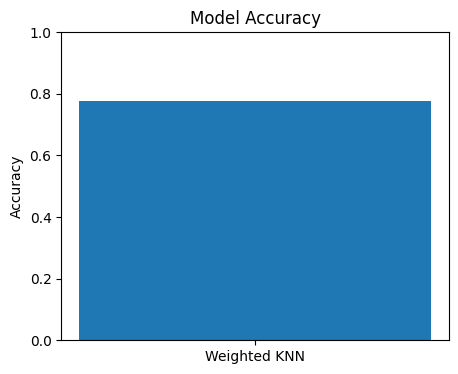

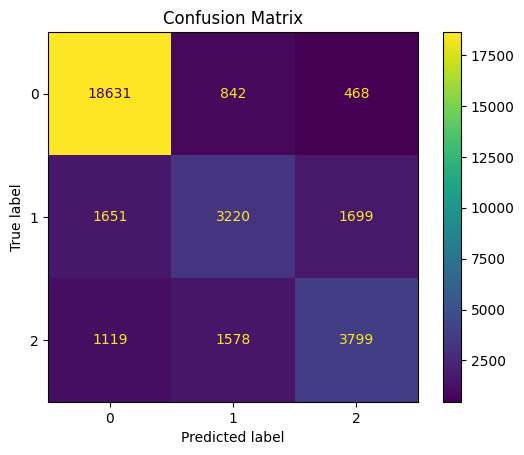

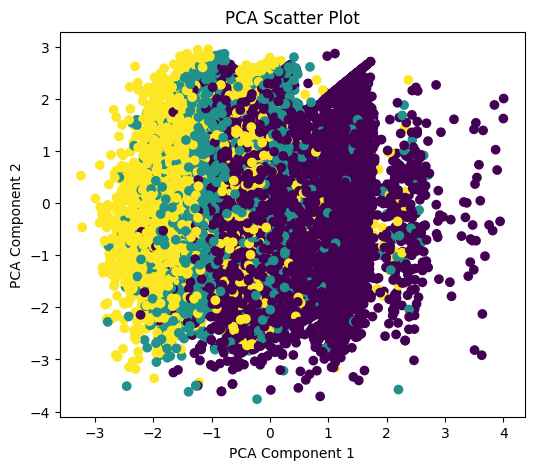

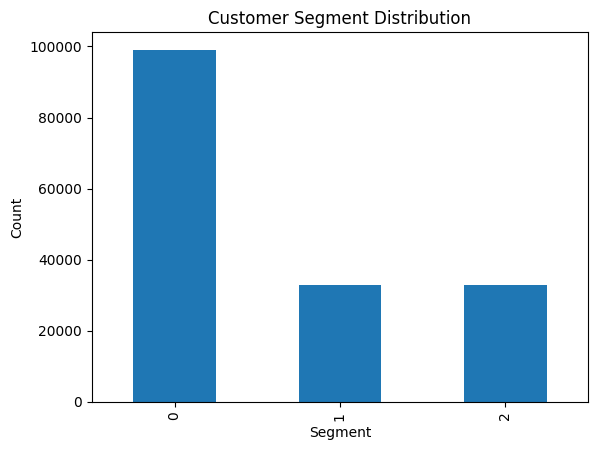

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Upload dataset
uploaded = files.upload()

# Read dataset
df = pd.read_csv("train.csv")

print(df.head())
print(df.info())

# Select required features
X = df[["CreditScore", "Age", "Balance", "NumOfProducts"]]

# Create Segment target safely
df["Segment"] = pd.qcut(
    df["Balance"],
    q=5,
    labels=False,
    duplicates="drop"
)

y = df["Segment"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Weighted KNN
model = KNeighborsClassifier(n_neighbors=5, weights="distance")
model.fit(X_train_pca, y_train)

# Prediction
y_pred = model.predict(X_test_pca)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy Graph
plt.figure(figsize=(5, 4))
plt.bar(["Weighted KNN"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

# Confusion Matrix Graph
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

# PCA Scatter Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot")
plt.show()

# Segment Distribution Graph
df["Segment"].value_counts().sort_index().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

# Bank Customer Segmentation

## Import Libraries

## Upload and Load Dataset

## Dataset Information

## Feature Selection

## Creating Customer Segments

## Train Test Split

## Feature Scaling

## PCA Dimensionality Reduction

## Weighted KNN Model

## Prediction

## Accuracy Score

## Confusion Matrix

## Classification Report

## Accuracy Visualization

## Confusion Matrix Visualization

## PCA Scatter Plot

## Customer Segment Distribution

## Conclusion

The machine learning model successfully segmented bank customers using financial attributes such as balance, age, credit score, and product usage. PCA and Weighted KNN helped improve visualization and classification performance.